In [2]:
# import pakietów
import numpy as np
from scipy import integrate

In [3]:
## definiujemy funkcję f
def f(x):
    if 0 <= x <= 1:
        return (1/3)**x
    else:
        return 0

In [4]:
## definiujemy funkcję g
def g(x):
    if 0 <= x <= 1:
        return (1+1j)*np.exp(x)
    else:
        return 0

In [5]:
## definiujemy przestrzeń Hilberta wraz z normą
def hilbert_space(func, interval):
    try:
        a, b = interval
        def integrand(x):
            return np.abs(func(x))**2
        
        result, error = integrate.quad(integrand, a, b)

        if np.isfinite(result) and result < np.inf:
            return True,result, np.sqrt(result)
        else:
            return False, np.inf
    except Exception as e:
        print(e)


In [6]:
hilbert_f,result_f, norm_f = hilbert_space(f, (-np.inf, np.inf))
hilbert_g,result_g, norm_g = hilbert_space(g, (-np.inf, np.inf))

In [7]:
print(f"Funkcja f(x) {'należy' if {hilbert_f} else 'nie należy'} do przestrzeni Hilberta, wynik = {result_f}, z normą = {norm_f}")
print(f"Funkcja g(x) {'należy' if {hilbert_g} else 'nie należy'} do przestrzeni Hilberta, wynik = {result_g}, z normą = {norm_g}")

Funkcja f(x) należy do przestrzeni Hilberta, wynik = 0.4045507673897055, z normą = 0.6360430546666677
Funkcja g(x) należy do przestrzeni Hilberta, wynik = 6.389056098930651, z normą = 2.5276582243117147


# Uzasadnienie
Z definicji, funkcja należy do przestrzeni Hilberta $L^2$($\mathbb{R}$), jeśli
$$
\int_{-\infty}^{\infty}|f(x)|^2dx
$$
jest skończona. 
\
Otrzymaliśmy wyniki:
- dla funkcji $f(x) \approx 0.405$,
- dla funkcji $g(x) \approx 6.389$,
co oznacza, że całka z $|f(x)|^2$ oraz $|g(x)|^2$ na całej osi rzeczywistej jest skończona, zatem funkcje $|f(x)|$ i $|g(x)|$ należą do przestrzeni Hilberta $L^2(\mathbb{R})$.
\
Dodatkowo możemy zauważyć, że w obu przypadkach mamy \
$\texttt{result, error = integrate.quad(integrand, a, b)}$, gdzie $\texttt{integrand(x) = np.abs(func(x))**2}$. \
Skoro wyniki $\texttt{result}$ dla obu funkcji są skończone to oznacza to, że całki istnieją i są zbieżne.


In [8]:
#definiujemy iloczyn skalarny
def inner_product(func1, func2, interval):
    
    a, b = interval

    def integrand(x):
        return func1(x) * np.conj(func2(x))

    def real_part(x):
        return np.real(integrand(x))

    def imag_part(x):
        return np.imag(integrand(x))

    real_integral, error1 = integrate.quad(real_part, a, b)
    imag_integral, error2 = integrate.quad(imag_part, a, b)
    result = real_integral + 1j * imag_integral

    return result

In [9]:
iloczyn_skalarny = inner_product(f, g,(-np.inf, np.inf))

In [10]:
print(f"Iloczyn skalarny funkcji f(x) i g(x)= {iloczyn_skalarny}")

Iloczyn skalarny funkcji f(x) i g(x)= (0.9522754055163373-0.9522754055163373j)


# Wnioski
Ponieważ wartości całek $\int|f(x)|^2dx$ oraz $\int|g(x)|^2dx$ okazały się skończone, obie funkcje $f(x)$ i $g(x)$ należą do przestrzeni Hilberta $L^2(\mathbb{R})$. Oznacza to, że są one funkcjami o skończonej normie $L^2$. 
\
Ponieważ przestrzeń $L^2(\mathbb{R})$ jest również przestrzenią Banacha, funkcje $f$ i $g$ też należą (z definicji) do przestrzeni Banacha $L^2(\mathbb{R})$. Dodatkowo, obie te funkcje są równe zero wszędzie poza przedziałem [0,1] i są ograniczone, dlatego należą do wszystkich przestrzeni Banacha $L^p(\mathbb{R})$ dla $1\leq p \leq \infty$.

Obliczony iloczyn skalarny $<f,g>\approx 0.9523 - 0.9523i$ jest skończony i różny od zera, co potwierdza, że funkcje są elementami przestrzeni Hilberta $L^2(\mathbb{R})$ oraz że nie są względem siebie ortogonalne.

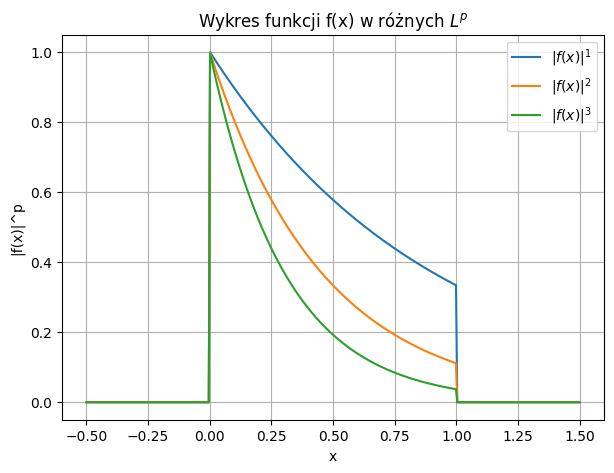

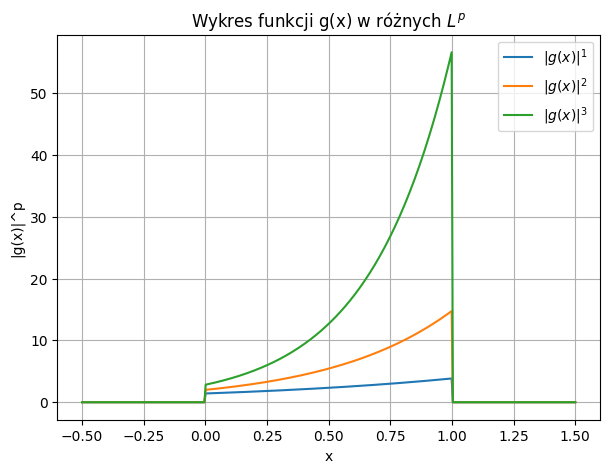

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# określamy najpierw zakres osi x 
x = np.linspace(-0.5, 1.5, 400)

# obliczamy wartości funkcji i modułów
f_vals = np.array([f(xi) for xi in x])
g_vals = np.array([g(xi) for xi in x])
abs_f = np.abs(f_vals)
abs_g = np.abs(g_vals)

# wartości p dla przestrzeni L^p
p_values = [1, 2, 3]

# wykres dla funkcji f(x) dla L1,L2,L3
plt.figure(figsize=(7, 5))
for p in p_values:
    plt.plot(x, abs_f**p, label=fr'$|f(x)|^{p}$')
plt.title("Wykres funkcji f(x) w różnych $L^p$")
plt.xlabel("x")
plt.ylabel("|f(x)|^p")
plt.grid(True)
plt.legend()
plt.show()

# wykres dla funkcji g(x) dla L1,L2,L3
plt.figure(figsize=(7, 5))
for p in p_values:
    plt.plot(x, abs_g**p, label=fr'$|g(x)|^{p}$')
plt.title("Wykres funkcji g(x) w różnych $L^p$")
plt.xlabel("x")
plt.ylabel("|g(x)|^p")
plt.grid(True)
plt.legend()
plt.show()

Z wykresów widać, że dla funkcji $f(x)$ podnoszenie do wyższych potęg $p$ spowalnia spadek wartości, natomiast dla funkcji $g(x)$ wyższe $p$ powoduje szybszy wzrost wartości $|g(x)|^p$.
# Wniosek
Podnoszenie wartości funkcji do potęgi $p$ w przestrzeniach $L^p$ wzmacnia wpływ dużych wartości i tłumi wpływ małych wartości. Dlatego funkcje mniejsze niż 1 ,,spowalniają spadek'', a funkcje większe niż 1 ,,przyspieszają wzrost'' dla rosnącego $p$.

Dla funkcji ograniczonych na przedziale $[0,1]$ zachodzi zależność
$$
L^3 \subseteq L^2 \subseteq L^1,
$$
więc jeśli funkcja należy do $L^2$, to należy także do wszystkich $L^p$ dla $p\leq 2$.